# **Exploring the Housing Market in Ames, Iowa**

## **Goal**

1. How have houses changed in their features over the years?

2. How have market dynamics shifted between properties designed for single households, such as single‑family homes and townhouses, and those designed for multiple households or shared living, such as duplexes and two‑family conversions, over time?

3. Which features make houses sell best?

## **Introduction**

The housing market affects everyone, from big real estate investors to families looking for a home. It's a complicated system, with prices and trends shifting constantly over time. In this report, we aim to make sense of these changes and provide a clearer picture of how the market has evolved. To do this, we'll analyze data from 1,460 property sales recorded between 2006 and 2010. Within this dataset, our focus will be on....


The data was collected by De Cock and recorded 1460 properties in Ames, IA.

Brief description of columns:

**1. Identification**
- **Id:** Property ID (unique identifier).

__2. Sale Information__
- **SalePrice:** Target variable — final selling price.
- **MoSold:** Month sold.
- **YrSold:** Year sold.

__3. Lot & Land__
- **MSSubClass:** Dwelling type (e.g., 1-story, 2-story).
- **MSZoning:** Zoning classification.
- **LotArea:** Lot size (sq ft).

__4. Building & Construction__

- **BldgType:** Building type (Single-family, Duplex).
- **HouseStyle:** House style (1-story, 2-story, split-level).
- **YearBuilt:** Year built.
- **Exterior1st/Exterior2nd:** Exterior covering materials.
- **MasVnrType:** Masonry veneer type.
- **ExterQual:** Exterior quality.
- **ExterCond:** Exterior condition.

__5. Interior Features__

- **GrLivArea:** Above-ground living area.
- **BsmtFullBath/BsmtHalfBath:** Basement bathrooms.
- **FullBath/HalfBath:** Bathrooms above ground.
- **BedroomAbvGr:** Bedrooms above ground.
- **TotRmsAbvGrd:** Total rooms above ground.



**This dataset represents the sale of properties in Ames, Iowa, where every single record represents a sale of individual house.
There are identification, land lot information, house characteristics, exterior, sales information and other features describing each house. The data of selling houses spans from 2006 to 2010.**

### __Import Libraries__

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import sidetable
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import statsmodels.api as sm

### __Display Setting__

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")
# set the decimal places to 2
pd.set_option("display.float_format", "{:.2f}".format)

### **Basic Understanding & Data Ingestion**

In [3]:
path = Path.cwd().parent
data_path = path.joinpath("data", "raw")
files = []
for file in data_path.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [4]:
# Read train and test
train_data = pd.read_csv(files[2])
test_data = pd.read_csv(files[1])
print("Training Dataset:")
display(train_data.head(1))
print("\n")
print("Testing Dataset:")
display(test_data.head(1))


Training Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500




Testing Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal


In [5]:
# Basic info of datasets
print(f"Training Dataset Shape : {train_data.shape}")
print(f"Testing Dataset Shape : {test_data.shape}")


Training Dataset Shape : (1460, 81)
Testing Dataset Shape : (1459, 80)


In [6]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

train_data.columns = train_data.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")#.str.lower()
test_data.columns = test_data.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [7]:
# Selecting columns for analysis in this notebook and define new train and test datasets
cols = ['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType',
    'HouseStyle', 'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'MasVnrArea', 'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
    'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold', 'YrSold', 'SalePrice']
    
df_train = train_data[cols]


In [8]:
new_cols = [x for x in cols if x != "SalePrice"]
df_test = test_data[new_cols]

### **Columns Formatting and Consistency**

In [9]:
dtype_df = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique'])
dtype_df['Dtype'] = df_train.dtypes
dtype_df['nunique'] = df_train.nunique()
dtype_df['unique'] = [df_train[col].unique() for col in df_train.columns]
dtype_df


,Dtype,nunique,unique
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,..."
MSZoning,object,5,"[RL, RM, C (all), FV, RH]"
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."
BldgType,object,5,"[1Fam, 2fmCon, Duplex, TwnhsE, Twnhs]"
HouseStyle,object,8,"[2Story, 1Story, 1.5Fin, 1.5Unf, SFoyer, SLvl,..."
YearBuilt,int64,112,"[2003, 1976, 2001, 1915, 2000, 1993, 2004, 197..."
Exterior1st,object,15,"[VinylSd, MetalSd, Wd Sdng, HdBoard, BrkFace, ..."
Exterior2nd,object,16,"[VinylSd, MetalSd, Wd Shng, HdBoard, Plywood, ..."
MasVnrType,object,3,"[BrkFace, nan, Stone, BrkCmn]"


### **Exploratory Data Analysis with Charts**

Let's explore the questions that were outlined in the goal section:



**`Question 1.` How have houses changed in their features over the years?**

In [10]:
# Create a new column for decade bins
df_train["DecadeBuilt"] = (df_train['YearBuilt']//10)*10

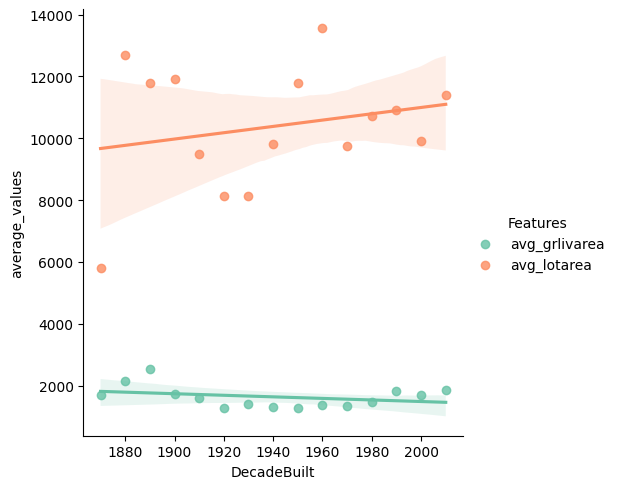

In [11]:
num_cols = ['GrLivArea', 'LotArea']
cat_cols = ['BedroomAbvGr', 'TotRmsAbvGrd', 'FullBath', 'HalfBath']

avg_features = (
    df_train.groupby(['DecadeBuilt'])[num_cols].mean()
    )
avg_features.columns = ["avg_"+col.lower() for col in avg_features.columns]
df_features = avg_features.reset_index()

# Reshape the long format
df_vars = df_features.melt(
    id_vars="DecadeBuilt",
    value_vars=['avg_grlivarea','avg_lotarea'],
    var_name="Features", value_name="average_values"
)
df_vars.head()
#fig, ax = plt.subplots(1, 2, figsize=(15, 8))
sns.lmplot(
    data=df_vars, 
    x="DecadeBuilt", y="average_values", 
    hue="Features", palette=sns.color_palette("Set2", 6)
);



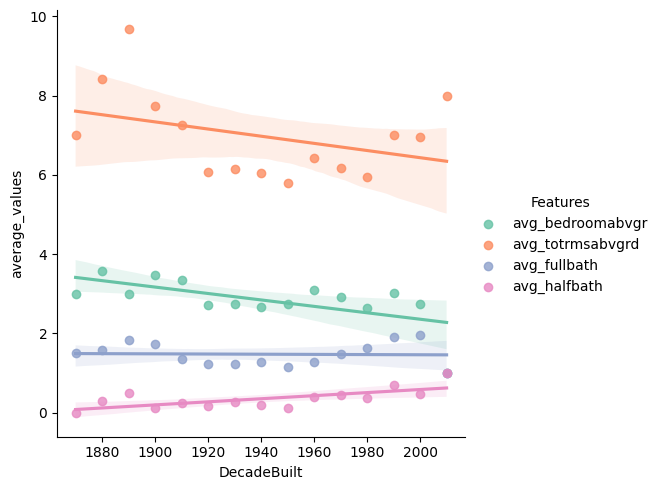

In [12]:
avg_cat = (
    df_train.groupby(['DecadeBuilt'])[cat_cols].mean()
    )
avg_cat.columns = ["avg_"+col.lower() for col in avg_cat.columns]
df_cat = avg_cat.reset_index()
# Reshape the long format
df_dimensions = df_cat.melt(
    id_vars="DecadeBuilt",
    value_vars=['avg_bedroomabvgr','avg_totrmsabvgrd', 'avg_fullbath', 'avg_halfbath'],
    var_name="Features", value_name="average_values"
)
df_dimensions.head()
sns.lmplot(
    data=df_dimensions, 
    x="DecadeBuilt", y="average_values", 
    hue="Features", palette=sns.color_palette("Set2", 4)
);


In [13]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType', 'HouseStyle',
       'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold',
       'YrSold', 'SalePrice', 'DecadeBuilt'],
      dtype='object')

In [14]:
import statsmodels.formula.api as smf
model = smf.ols("DecadeBuilt ~ LotArea  + MasVnrArea", data=df_train).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            DecadeBuilt   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     76.91
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.79e-32
Time:                        15:22:50   Log-Likelihood:                -6910.0
No. Observations:                1452   AIC:                         1.383e+04
Df Residuals:                    1449   BIC:                         1.384e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1961.9339      1.130   1735.934      0.0

In [15]:
import statsmodels.formula.api as smf
model = smf.ols("SalePrice ~ DecadeBuilt+ BedroomAbvGr+ FullBath + HalfBath + TotRmsAbvGrd", data=df_train).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     357.0
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          8.06e-250
Time:                        15:22:51   Log-Likelihood:                -17959.
No. Observations:                1460   AIC:                         3.593e+04
Df Residuals:                    1454   BIC:                         3.596e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1.856e+06   1.14e+05    -16.243   

In [16]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType', 'HouseStyle',
       'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold',
       'YrSold', 'SalePrice', 'DecadeBuilt'],
      dtype='object')

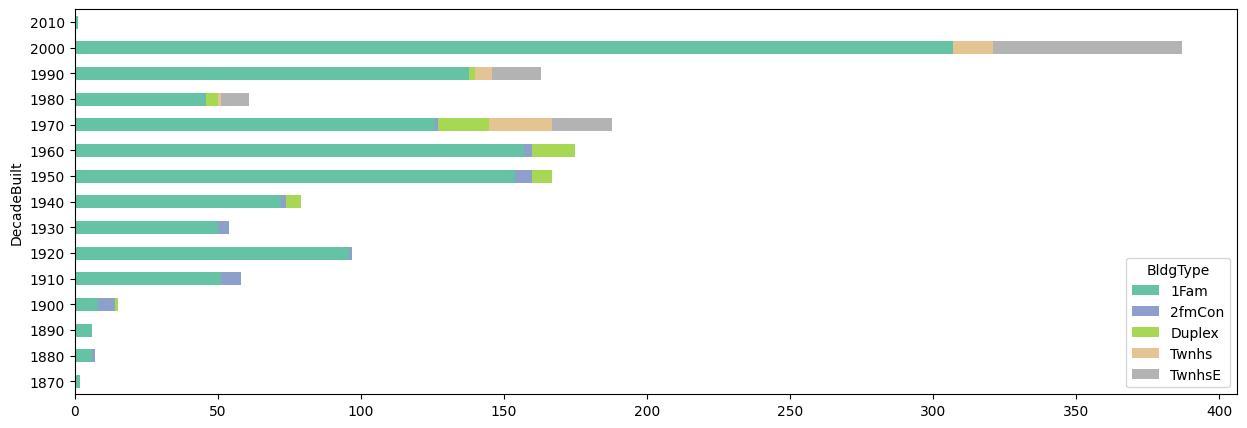

In [17]:
df_train.groupby(['DecadeBuilt', 'BldgType']).size().unstack(fill_value=0).plot(kind='barh', colormap="Set2", stacked=True, figsize=(15, 5));

Single‑family homes have been the main type of housing built over time, and its peak during the mid‑20th century. In more recent years, the mix of building types has become more diversified. Townhouses, which were almost nonexistent in earlier decades, have gradually increased as cities grow denser and people look for smaller, easier‑to‑maintain homes. Duplexes have stayed at a low but steady level, while two‑family conversions have declined as newer homes are built to serve those needs directly. Overall, the data shows a shift from a market dominated by single‑family homes to one with a broader range of housing types.

**`Question 2.` How have market dynamics shifted between properties designed for single households, such as single‑family homes and townhouses, and those designed for multiple households or shared living, such as duplexes and two‑family conversions, over time?**

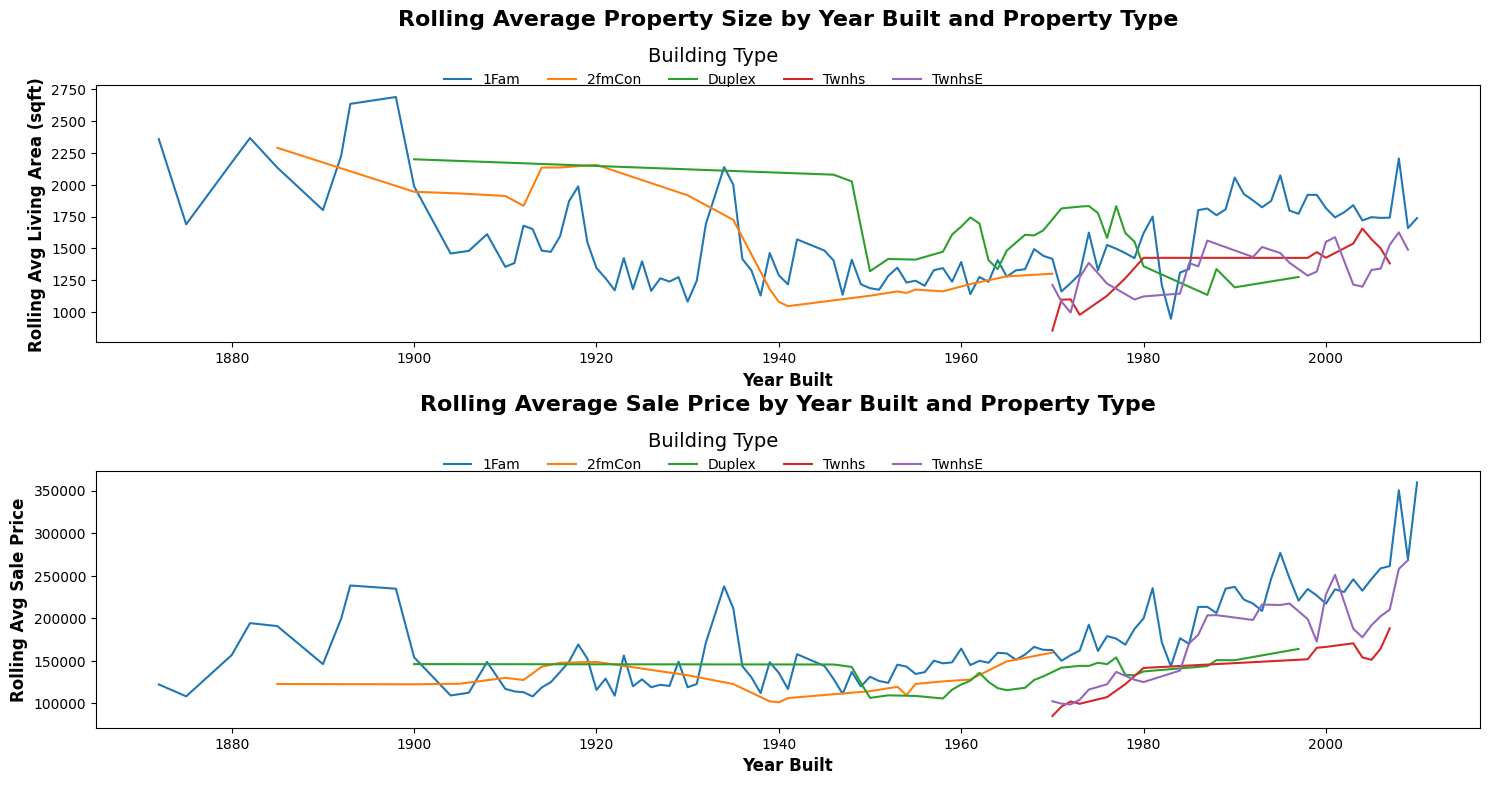

In [57]:

# df has columns: YearBuilt, BldgType, GrLivArea (property size), SalePrice

# Sort by YearBuilt to ensure rolling works correctly
df = df_train.sort_values("YearBuilt")

# Group by property type
grouped = df.groupby("BldgType")

# Compute rolling averages within each property type
df["rolling_size"] = grouped["GrLivArea"].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
df["rolling_price"] = grouped["SalePrice"].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Now you can also group by YearBuilt + BldgType to see yearly averages
yearly = df.groupby(["YearBuilt", "BldgType"]).agg({
    "rolling_size": "mean",
    "rolling_price": "mean"
}).reset_index()

# plot rolling size and sale price
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
sns.lineplot(data=yearly, x="YearBuilt", y="rolling_size", hue="BldgType", ax=ax[0])
ax[0].set_title("Rolling Average Property Size by Year Built and Property Type", fontsize=16, fontweight='bold', y=1.20)
ax[0].set_xlabel("Year Built", fontsize=12, fontweight='bold')
ax[0].set_ylabel("Rolling Avg Living Area (sqft)", fontsize=12, fontweight='bold')
ax[0].legend(title="Building Type", title_fontsize=14, loc='upper right', bbox_to_anchor=(0.65, 1.20), ncol=6, frameon=False)

# Plot rolling sale price
sns.lineplot(data=yearly, x="YearBuilt", y="rolling_price", hue="BldgType", ax=ax[1])
ax[1].set_title("Rolling Average Sale Price by Year Built and Property Type", fontsize=16, fontweight='bold', y=1.20)
ax[1].set_xlabel("Year Built", fontsize=12, fontweight='bold')
ax[1].set_ylabel("Rolling Avg Sale Price", fontsize=12, fontweight='bold')
ax[1].legend(title="Building Type", title_fontsize=14, loc='upper right', bbox_to_anchor=(0.65, 1.20), ncol=6, frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()



In [18]:
u = df_train.groupby(['BldgType']).agg(
    avg_rooms = ('TotRmsAbvGrd', 'mean'),
    avg_bed_rooms = ('BedroomAbvGr', 'mean')
).reset_index()
u

,BldgType,avg_rooms,avg_bed_rooms
0,1Fam,6.60,2.93
1,2fmCon,7.23,3.35
2,Duplex,7.69,3.56
3,Twnhs,5.56,2.37
4,TwnhsE,5.24,1.95


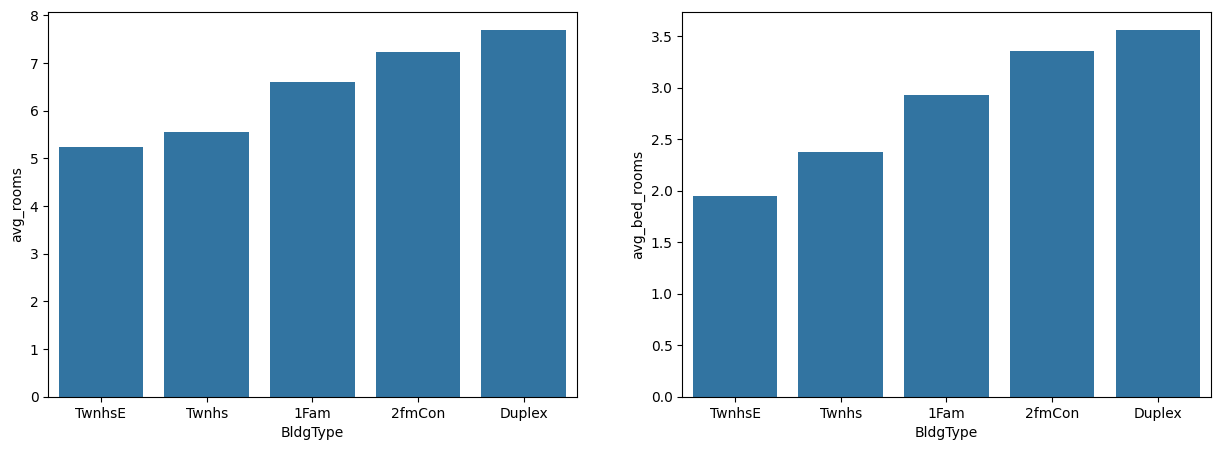

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=u.sort_values(by='avg_rooms', ascending=True), x='BldgType', y='avg_rooms', ax=ax[0])
sns.barplot(data=u.sort_values(by='avg_bed_rooms', ascending=True), x='BldgType', y='avg_bed_rooms', ax=ax[1]);

In [20]:
v = df_train.groupby(['HouseStyle']).agg(
    avg_rooms = ('TotRmsAbvGrd', 'mean'),
    avg_bed_rooms = ('BedroomAbvGr', 'mean')
).reset_index()
v

,HouseStyle,avg_rooms,avg_bed_rooms
0,1.5Fin,6.71,3.08
1,1.5Unf,4.71,2.07
2,1Story,5.90,2.59
3,2.5Fin,10.62,4.62
4,2.5Unf,8.27,3.27
5,2Story,7.58,3.29
6,SFoyer,4.89,2.05
7,SLvl,6.23,2.89


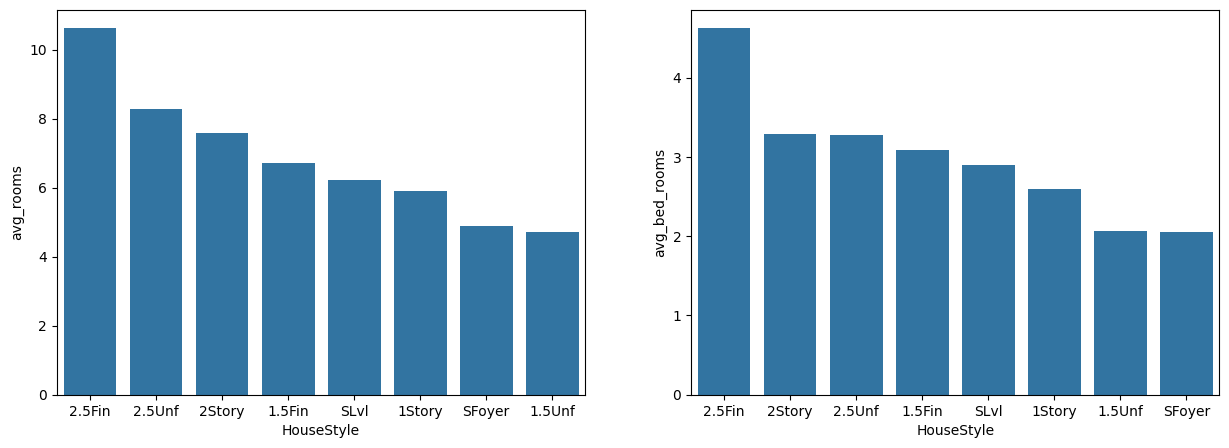

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=v.sort_values(by="avg_rooms", ascending=False), x='HouseStyle', y='avg_rooms', ax=ax[0])
sns.barplot(data=v.sort_values(by='avg_bed_rooms', ascending=False), x='HouseStyle', y='avg_bed_rooms', ax=ax[1]);

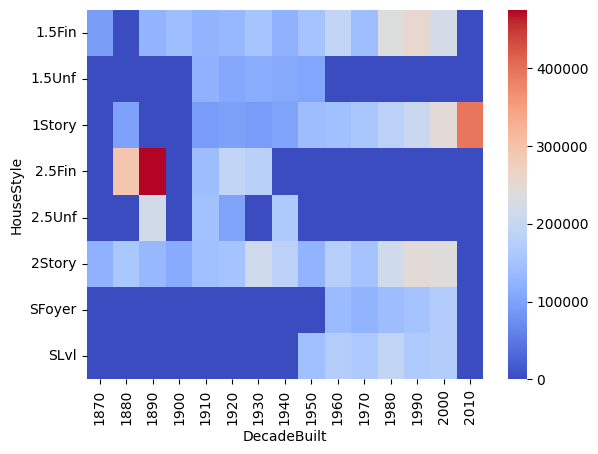

In [22]:
j= df_train.pivot_table(index='HouseStyle', columns='DecadeBuilt', values='SalePrice', aggfunc='mean').fillna(0)
sns.heatmap(j, cmap='coolwarm');

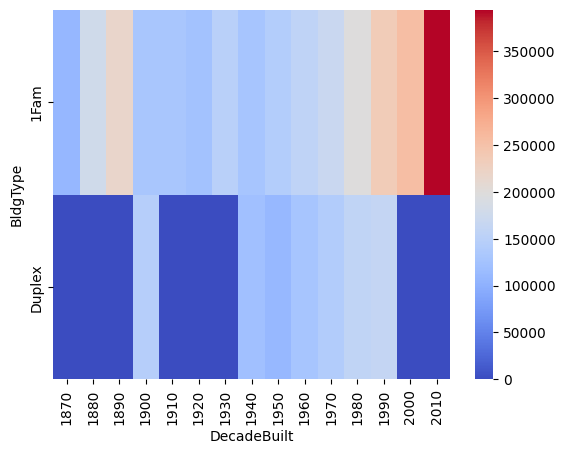

In [23]:
k= df_train.query("BldgType.isin(['1Fam', 'Duplex'])").pivot_table(index='BldgType', columns='DecadeBuilt', values='SalePrice', aggfunc='mean').fillna(0)
sns.heatmap(k, cmap='coolwarm');

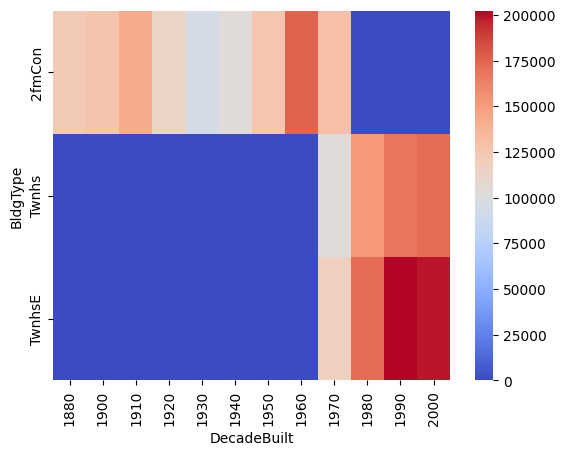

In [24]:
k= df_train.query("BldgType.isin(['TwnhsE', 'Twnhs', '2fmCon'])").pivot_table(index='BldgType', columns='DecadeBuilt', values='SalePrice', aggfunc='mean').fillna(0)
sns.heatmap(k, cmap='coolwarm');

In [25]:
df_train['BldgType'].value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

In [26]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType', 'HouseStyle',
       'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold',
       'YrSold', 'SalePrice', 'DecadeBuilt'],
      dtype='object')

**`Question 3.` Which features make houses sell best?**

In [27]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType', 'HouseStyle',
       'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold',
       'YrSold', 'SalePrice', 'DecadeBuilt'],
      dtype='object')

In [32]:
cols = ['YearBuilt', 'LotArea', 'GrLivArea', 'BldgType', 
        'HouseStyle']
# Create log-transformed target
df_train['LogSalePrice'] = np.log(df_train['SalePrice'])+1

# Define formula
formula = "LogSalePrice ~ YearBuilt + LotArea + GrLivArea + C(BldgType) + C(HouseStyle)"

# Fit OLS regression
model = smf.ols(formula=formula, data=df_train).fit()

# Print summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     304.6
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:45:24   Log-Likelihood:                 271.74
No. Observations:                1460   AIC:                            -513.5
Df Residuals:                    1445   BIC:                            -434.2
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [43]:
# Select features
cols = ['YearBuilt', 'LotArea', 'GrLivArea', 'BldgType']
X = df_train[cols]

# Convert categorical to dummies
X_dummy = pd.get_dummies(X, drop_first=True)
X_dummy = X_dummy.astype(int)


# Target
y = np.log(df_train['SalePrice'])+1

# Add constant
X_dummy = sm.add_constant(X_dummy)

# Fit model
model = sm.OLS(y, X_dummy).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     566.3
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:05:22   Log-Likelihood:                 229.60
No. Observations:                1460   AIC:                            -443.2
Df Residuals:                    1452   BIC:                            -400.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0214      0.383     

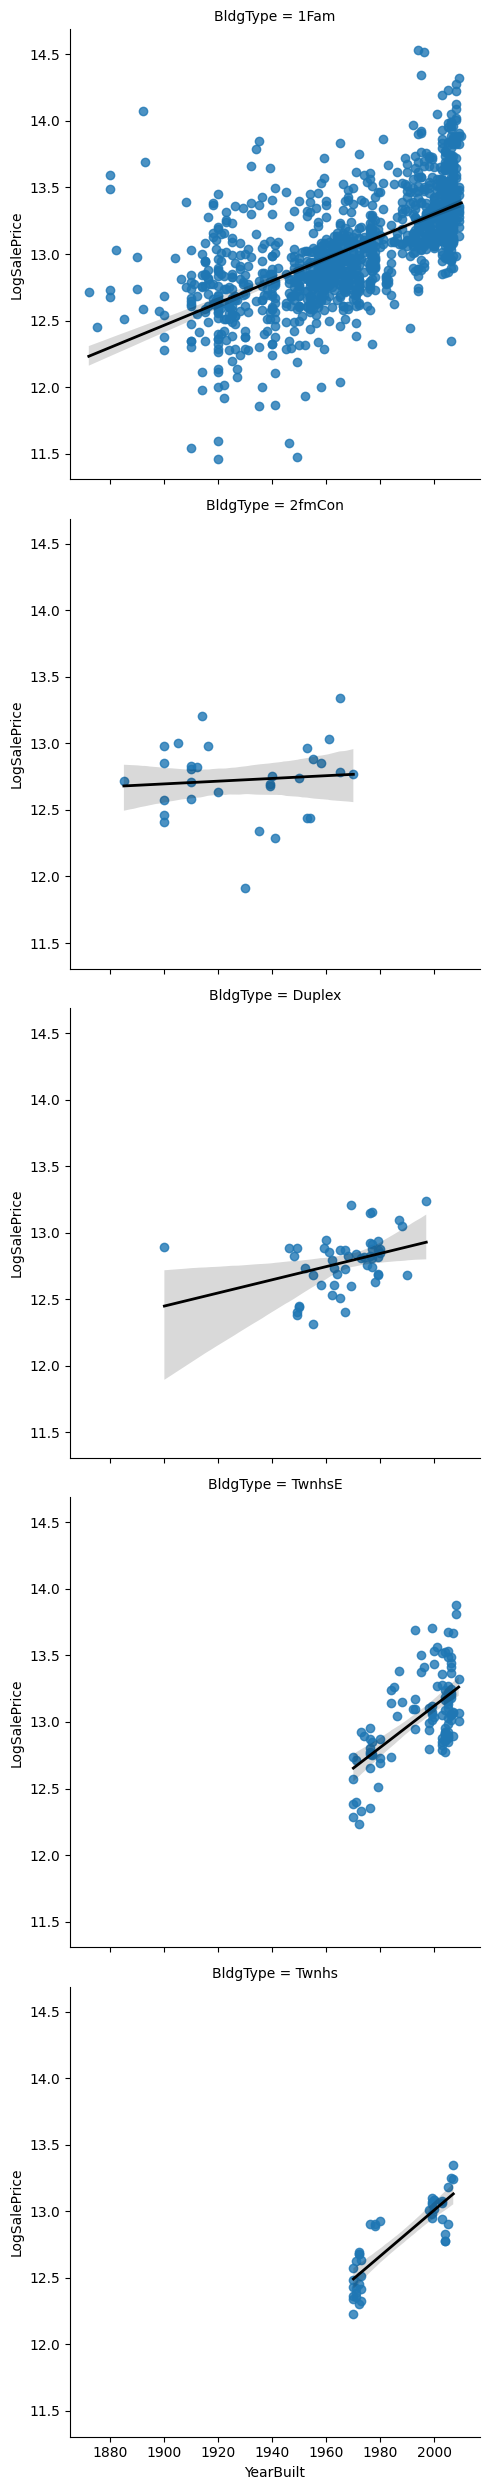

In [40]:
sns.lmplot(
    data=df_train,
    x="YearBuilt", y="LogSalePrice",
    row='BldgType', ci=95,
    line_kws={'lw':2, 'ls':'-', "color":'k'},
    palette = sns.color_palette("Set2", 5)
);

In [44]:
X_dummy.head()

,const,YearBuilt,LotArea,GrLivArea,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,1.00,2003,8450,1710,0,0,0,0
1,1.00,1976,9600,1262,0,0,0,0
2,1.00,2001,11250,1786,0,0,0,0
3,1.00,1915,9550,1717,0,0,0,0
4,1.00,2000,14260,2198,0,0,0,0
